# PCA and PCR

The materials used in this tutorial are based on the applied exercises provided in the book "An Introduction to Statistical Learning with Applications in R/Python" (ISLR). We are trying to demonstrate how to implement Principle Component Regression to deal with the curse of dimensionality.
    
We have discussed that if the number of predictors is approximately equal to or larger than the number of observations, we can easily yield an over-fitted model. The problem of high dimension is very common in, for example, image processing, bio-informatics, etc. In the following exercises, we will show you how to use PCR.


## 1. Predict the number of applications in the College data

In the applied class on linear model selection and regularization, we demonstrate how to penalize the linear regression with $L_1$ and $L_2$ regularization. In this exercise, we will predict the number of applications received using the other variables in the College data set with PCR.

In [1]:
import pandas as pd

college_df = pd.read_csv("College.csv")
college_df = college_df.set_index(college_df.columns[0])
college_df.index.name = None
college_df.describe(include='all')

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
unique,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,565,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,NaN,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,NaN,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,NaN,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,NaN,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,NaN,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000


### 1.1 Split the data set into a training set and a test set. 
As what we usually do, we should split the whole data set into a training set and a test set. We then fit our model on the training set and test its performance on the test set. Here, we randomly choose half of the data to be training data, the other half to be test data.

In [2]:
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Randomly sample row indices for training
train_indices = np.random.choice(college_df.index, int(len(college_df) / 2), replace=False)
test_indices = np.setdiff1d(college_df.index, train_indices)

College_train = college_df.loc[train_indices]
College_test = college_df.loc[test_indices]

### 1.2 Fit a PCR model

Fit a PCR model on the training set, with M chosen by cross-validation. Report the test error obtained, along with the value of M selected by cross-validation. In this task, the Python library that you need is <a href="https://scikit-learn.org/stable/">scikit-learn</a>. If you're unfamiliar with its usage for PCR, you can refer to the combination of PCA (for dimensionality reduction) and Linear Regression (for the regression part) in the scikit-learn documentation:
- <a href="https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html">PCA in scikit-learn</a>
- <a href="https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html">Linear Regression in scikit-learn</a>

For a more complete understanding of PCR implementation in Python, you can also refer to various online tutorials and resources that explain the combination of PCA and Linear Regression using scikit-learn.

In [4]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, cross_val_predict, KFold
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
# Separate predictors and response
X = College_train.drop('Apps', axis=1)
y = College_train['Apps']

# Apply LabelEncoder to categorical columns
categorical_cols = X.select_dtypes(include='object').columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize KFold and PCA
kf = KFold(n_splits=10, shuffle=True, random_state=1)
pca = PCA()

# Lists to hold results
components = list(range(1, X.shape[1] + 1))
RMSEP = []  # Placeholder for intercept-only RMSEP
adjRMSEP = []  # Placeholder for intercept-only adjRMSEP
explained_var_apps = []

# Cross-validation loop
for n_comps in [0] + components:  # 0 components for intercept-only model
    mse_values = []
    
    for train_index, test_index in kf.split(X_scaled):
        X_train, X_test = X_scaled[train_index], X_scaled[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        if n_comps == 0:  # Intercept-only model
            y_pred = [y_train.mean()] * len(y_test)
        else:
            pcr = Pipeline([
                ('pca', PCA(n_components=n_comps)),
                ('linear', LinearRegression())
            ])
            pcr.fit(X_train, y_train)
            y_pred = pcr.predict(X_test)
            
        mse_values.append(mean_squared_error(y_test, y_pred))
    
    
    # Calculate RMSEP and adjRMSEP
    mean_mse = np.mean(mse_values)
    rmsep = np.sqrt(mean_mse)
    nk_values = [len(test_index) for _, test_index in kf.split(X_scaled)]
    nL = X_scaled.shape[0]
    adjustment_term = sum([(nk/nL) * mse for nk, mse in zip(nk_values, mse_values)]) / nL
    adj_rmsep = rmsep - np.sqrt(adjustment_term)
    
    RMSEP.append(rmsep)
    if n_comps == 0: 
        adjRMSEP.append(rmsep)
    else:
        adjRMSEP.append(adj_rmsep)

    # Compute variance explained in Apps (skip for intercept-only model)
    if n_comps > 0:
        pcr.fit(X_scaled, y)
        y_train_pred = pcr.predict(X_scaled)
        r2 = r2_score(y, y_train_pred)
        explained_var_apps.append(r2 * 100)

# Create DataFrames
result_df_rmsep = pd.DataFrame(dict(zip(['(Intercept)'] + [f'{i} comps' for i in components], zip(RMSEP, adjRMSEP)))).T
result_df_rmsep.columns = ['CV', 'adjCV']

explained_variance = pca.fit(X_scaled).explained_variance_ratio_.cumsum() * 100
result_df_variance = pd.DataFrame(dict(zip([f'{i} comps' for i in components], zip(explained_variance, explained_var_apps)))).T
result_df_variance.columns = ['X', 'Apps']

# Display
print(f"Data:")
print(f"X dimension: {X.shape[0]} {X.shape[1]}")
print(f"Y dimension: {y.shape[0]} 1")  # y is a Series, so it only has one dimension
print(f"Number of components considered: {X.shape[1]}")
print("\nVALIDATION: RMSEP")
print("Cross-validated using 10 random segments.")
print(result_df_rmsep.T)
print("\nTRAINING: % variance explained")
print(result_df_variance.T.round(2))

Data:
X dimension: 388 17
Y dimension: 388 1
Number of components considered: 17

VALIDATION: RMSEP
Cross-validated using 10 random segments.
       (Intercept)      1 comps      2 comps      3 comps      4 comps  \
CV     4246.137999  4139.434492  2379.416431  2386.261036  2387.423069   
adjCV  4246.137999  3929.152224  2258.485318  2264.985012  2266.087762   

           5 comps      6 comps      7 comps      8 comps      9 comps  \
CV     2177.095975  1981.317783  1925.923297  1930.427849  1902.702225   
adjCV  2066.433821  1880.593740  1828.025438  1832.300231  1805.980387   

          10 comps     11 comps     12 comps     13 comps     14 comps  \
CV     1906.622895  1918.654301  1909.727922  1927.651432  1940.694846   
adjCV  1809.700389  1821.123763  1812.647271  1829.663777  1842.040779   

          15 comps     16 comps     17 comps  
CV     1913.070213  1525.541207  1440.037397  
adjCV  1815.805190  1448.032194  1366.855215  

TRAINING: % variance explained
      1 comps  2

In the summary, there are two main results, namely the validation error and the cumulative percentage of variance explained using n components. The cross validation results are computed for each number of components used so that you can easily check the score with a particular number of components. The validation results are Root Mean Squared Error of Prediction (RMSEP). There are two cross-validation estimates: CV is the ordinary CV estimate, and adjCV is a bias-corrected CV estimate. Note that the percentage of variance explained in the predictors and in the response using different $M$ increases as $M$ increases.

X is the percentage of variance explained of your dataset, APPs the variance of your responce variable explained by your model (Like R-squared).
If is often simpler to judge the RMSEPs by plotting them, you can use the <font color="blue">plot()</font> function.

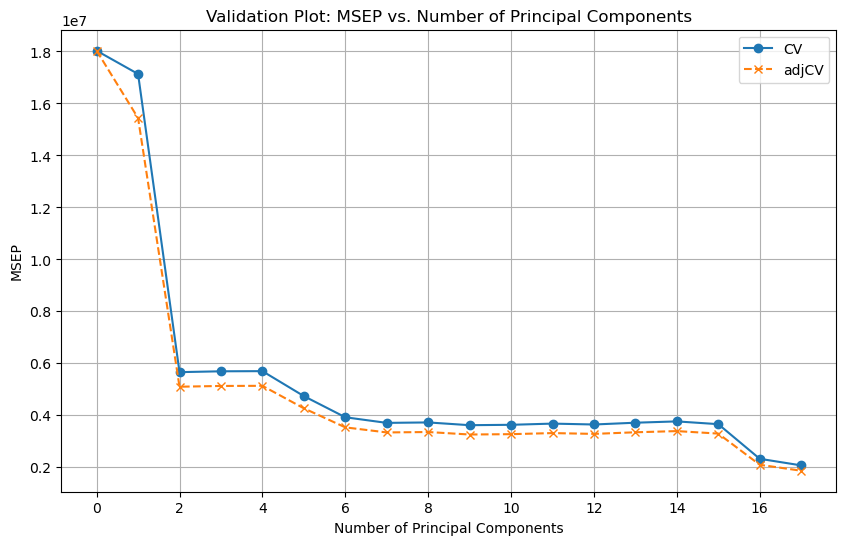

In [6]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

MSEP = [value**2 for value in RMSEP]
adjMSEP = [value**2 for value in adjRMSEP]

num_components = range(0, len(MSEP)) 

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(num_components, MSEP, marker='o', linestyle='-', label='CV')
ax.plot(num_components, adjMSEP, marker='x', linestyle='--', label='adjCV')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('MSEP')
ax.set_title('Validation Plot: MSEP vs. Number of Principal Components')
ax.legend(loc='upper right')
ax.grid(True)

# Setting x-ticks to be integer values
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.show()

The plot shows that the smallest cross-validation error occurs when $M = 16$, which is only one less than the total number of predictors in the data set. We might think about just performing least squares.

Now, we have found the lowest cross-validation error occurs when $M= 16$ components are used. We can compute the test MSE as follows

In [7]:
# Separate predictors and response
X_train = College_train.drop('Apps', axis=1)
y_train = College_train['Apps']
X_test = College_test.drop('Apps', axis=1)
y_test = College_test['Apps']

# Apply LabelEncoder to categorical columns
categorical_cols = X_train.select_dtypes(include='object').columns
for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])

categorical_cols = X_test.select_dtypes(include='object').columns
for col in categorical_cols:
    le = LabelEncoder()
    X_test[col] = le.fit_transform(X_test[col])
    
# Scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

scaler = StandardScaler()
X_test = scaler.fit_transform(X_test)

# Build PCR model with 16 components
pcr = Pipeline([
    ('pca', PCA(n_components=16)),
    ('linear_regression', LinearRegression())
])

pcr.fit(X_train, y_train)
y_pred = pcr.predict(X_test)

# Calculate Mean Squared Prediction Error
mse = mean_squared_error(y_test, y_pred)
print(mse)


1244418.1191413957


##  2. Predict per capital crime crate in the "Boston" data set

In this exercise, we compare the feature selection methods with PCR and PLS. 

In [14]:
boston_df = pd.read_csv("boston_dataset.csv")
boston_df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


Firstly, split the data set into a training set and a test set.

In [24]:
# Setup seed
np.random.seed(44)

# Create a random boolean array of the same length as the number of rows in Boston
train = np.random.choice([True, False], len(boston_df), replace=True)

# Negate the train array to get the test array
test = ~train

# Split the Boston dataframe into train and test sets
boston_train = boston_df[train]
boston_test = boston_df[test]

In the rest of the task, you are going to 
1. Try out some of the regression methods such as the lasso, ridge regression, and PCR Present and discuss results for the approaches that you consider.
1. Propose a model (or set of models) that seem to perform well on this data set, and justify your answer. Make sure that you are evaluating model performance using validation set error, cross-validation, or some other reasonable alternative, as opposed to using training error.
1. Does your chosen model involve all of the features in the data set? Why or why not? 

Let's start with Ridge regression model

ridge regression CV best value of lambda (one standard error): 64.424


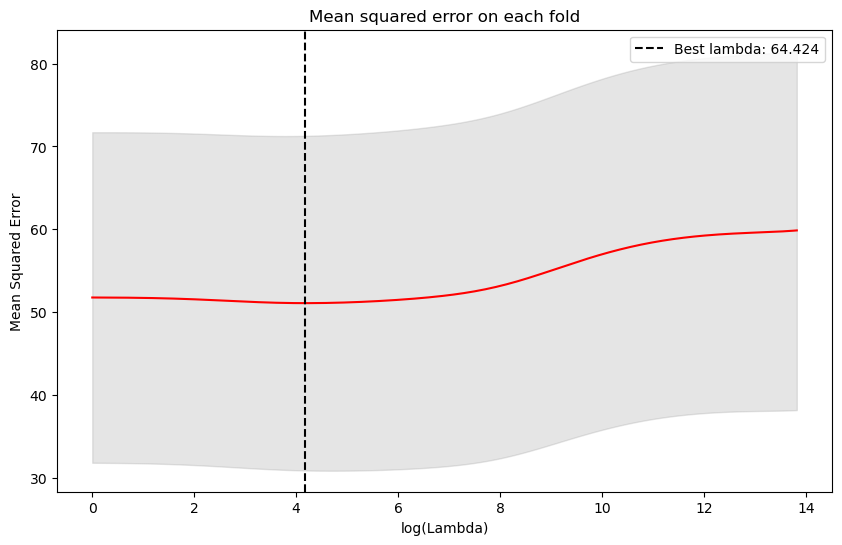

In [25]:
from sklearn.linear_model import RidgeCV

y = boston_train['crim']
X = boston_train.drop('crim', axis=1)

alphas = np.logspace(0, 6, 200)  # Expanding the range a bit
ridge_cv = RidgeCV(alphas=alphas, store_cv_values=True)
ridge_cv.fit(X, y)

mean_errors = np.mean(ridge_cv.cv_values_, axis=0)
std_errors = np.std(ridge_cv.cv_values_, axis=0)
print(f"ridge regression CV best value of lambda (one standard error): {ridge_cv.alpha_:.3f}")
plt.figure(figsize=(10, 6))
plt.plot(np.log(alphas), mean_errors, color='red')
plt.fill_between(np.log(alphas), mean_errors + np.sqrt(std_errors), mean_errors - np.sqrt(std_errors), color='grey', alpha=0.2)
plt.axvline(np.log(ridge_cv.alpha_), linestyle='--', color='black', label=f'Best lambda: {ridge_cv.alpha_:.3f}')
plt.xlabel('log(Lambda)')
plt.ylabel('Mean Squared Error')
plt.title('Mean squared error on each fold')
plt.legend()
plt.show()

Now, compute the test MSE:

In [26]:
# Prepare the design matrix for the test set
X_test = boston_test.drop('crim', axis=1)

# Predict using the trained model
Y_hat = ridge_cv.predict(X_test)

# Compute the mean squared error
MSE = mean_squared_error(boston_test['crim'], Y_hat)

print(f"Ridge regression test MSE= {MSE:.3f}")

Ridge regression test MSE= 41.037


Then, let's test the Lasso model. You only need to use <font color="brown">LassoCV, Lasso</font> in the <font color = "blue">sklearn.linear_model</font> library.

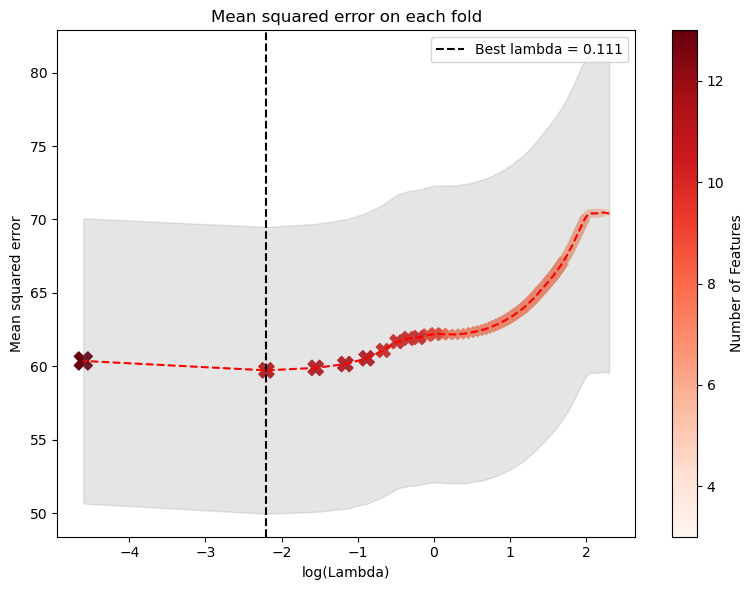

Best value of lambda (one standard error): 0.111
Lasso regression test MSE= 43.219


In [27]:
from sklearn.linear_model import LassoCV, Lasso

alphas_r = np.linspace(10, 0.01, 100)
lasso_cv = LassoCV(alphas=alphas_r, cv=10, max_iter=10000, tol=0.01)
lasso_cv.fit(X, y)

# Extracting mean square errors and alphas used during cross-validation
mse_means = np.mean(lasso_cv.mse_path_, axis=1)
mse_errors = np.std(lasso_cv.mse_path_, axis=1)
alphas = lasso_cv.alphas

# Get number of non-zero coefficients for each alpha
coef_counts = []
for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000, tol=0.01)
    lasso.fit(X, y)
    coef_counts.append(np.sum(lasso.coef_ != 0))

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
plot_line, = ax.plot(np.log(alphas), mse_means, color='red', linestyle='--')

coef_counts_normalized = [c ** 2 for c in coef_counts]

# Scatter plot to show number of non-zero coefficients
scatter = ax.scatter(np.log(alphas), mse_means, c=coef_counts, cmap="Reds", s=coef_counts_normalized, 
                     marker = 'X')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Number of Features')

ax.fill_between(np.log(alphas), mse_means + np.sqrt(mse_errors), mse_means - np.sqrt(mse_errors), color='grey', alpha=0.2)
ax.axvline(np.log(lasso_cv.alpha_), linestyle='--', color='black', label=f'Best lambda = {lasso_cv.alpha_:.3f}')

ax.set_xlabel('log(Lambda)')
ax.set_ylabel('Mean squared error')
ax.set_title('Mean squared error on each fold')
ax.legend()
fig.tight_layout()
plt.show()

best_alpha = lasso_cv.alpha_
print(f"Best value of lambda (one standard error): {best_alpha:.3f}")

# Predict using the trained model
Y_hat = lasso_cv.predict(X_test)

# Compute the mean squared error
MSE = mean_squared_error(boston_test['crim'], Y_hat)

print(f"Lasso regression test MSE= {MSE:.3f}")

Now, we try the PCR model by following what you have done in the first exercise.

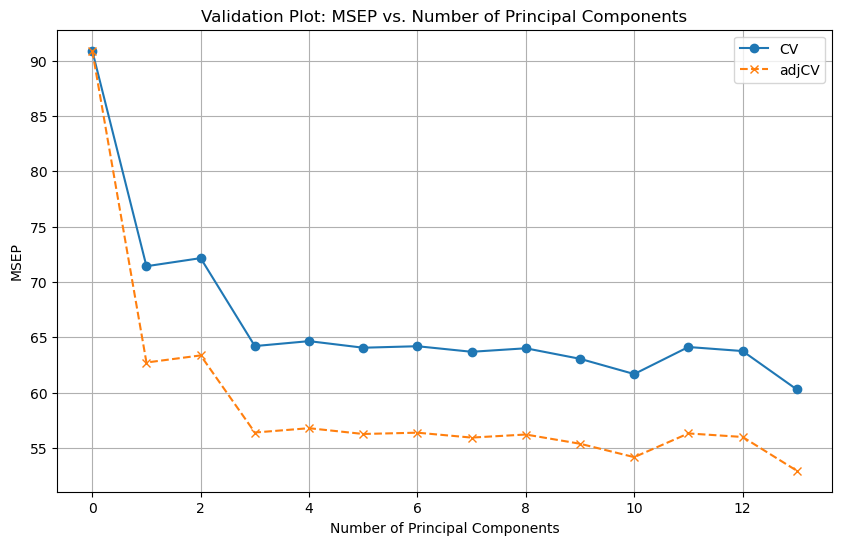

In [28]:
# Separate predictors and response
X = boston_train.drop('crim', axis=1)
y = boston_train['crim']


# Apply LabelEncoder to categorical columns
categorical_cols = X.select_dtypes(include='object').columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize KFold and PCA
kf = KFold(n_splits=10, shuffle=False)
pca = PCA()

# Lists to hold results
components = list(range(1, X.shape[1] + 1))
RMSEP = []  # Placeholder for intercept-only RMSEP
adjRMSEP = []  # Placeholder for intercept-only adjRMSEP
explained_var_apps = []

# Cross-validation loop
for n_comps in [0] + components:  # 0 components for intercept-only model
    mse_values = []
    
    for train_index, test_index in kf.split(X_scaled):
        X_train, X_test = X_scaled[train_index], X_scaled[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        if n_comps == 0:  # Intercept-only model
            y_pred = [y_train.mean()] * len(y_test)
        else:
            pcr = Pipeline([
                ('pca', PCA(n_components=n_comps)),
                ('linear', LinearRegression())
            ])
            pcr.fit(X_train, y_train)
            y_pred = pcr.predict(X_test)
            
        mse_values.append(mean_squared_error(y_test, y_pred))
    
    
    # Calculate RMSEP and adjRMSEP
    mean_mse = np.mean(mse_values)
    rmsep = np.sqrt(mean_mse)
    nk_values = [len(test_index) for _, test_index in kf.split(X_scaled)]
    nL = X_scaled.shape[0]
    adjustment_term = sum([(nk/nL) * mse for nk, mse in zip(nk_values, mse_values)]) / nL
    adj_rmsep = rmsep - np.sqrt(adjustment_term)
    
    RMSEP.append(rmsep)
    if n_comps == 0: 
        adjRMSEP.append(rmsep)
    else:
        adjRMSEP.append(adj_rmsep)

MSEP = [value**2 for value in RMSEP]
adjMSEP = [value**2 for value in adjRMSEP]

num_components = range(0, len(MSEP)) 

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(num_components, MSEP, marker='o', linestyle='-', label='CV')
ax.plot(num_components, adjMSEP, marker='x', linestyle='--', label='adjCV')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('MSEP')
ax.set_title('Validation Plot: MSEP vs. Number of Principal Components')
ax.legend(loc='upper right')
ax.grid(True)

# Setting x-ticks to be integer values
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.show()

The validation plot looks suggests that we should use 10 predictors.

In [34]:
# Separate predictors and response
X_train = boston_train.drop('crim', axis=1)
y_train = boston_train['crim']
X_test = boston_test.drop('crim', axis=1)
y_test = boston_test['crim']

# Build PCR model with 13 components
pcr = Pipeline([
    ('pca', PCA(n_components= 10)),
    ('linear_regression', LinearRegression())
])

# Scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

scaler = StandardScaler()
X_test = scaler.fit_transform(X_test)


pcr.fit(X_train, y_train)
y_pred = pcr.predict(X_test)

# Calculate Mean Squared Prediction Error
mse = mean_squared_error(y_test, y_pred)
print(f"PCR test MSE= {mse:.3f}")


PCR test MSE= 41.493


By looking at the test MSE, which model does give the lowest test MSE?